# Recap

### Векторные представления

#### Что нужно сделать, чтобы получить векторные представления слов?

In [1]:
import torch
import torch.nn as nn
import tqdm.auto as tqdm

Функция count_params предназначена для подсчета общего количества параметров в модели PyTorch, которые могут быть обучены (т.е. имеют requires_grad=True).

In [17]:
def count_params(torch_model) :
    return sum([p.numel() for p in torch_model.parameters() if p.requires_grad])

'''
torch_model.parameters(): Эта функция возвращает генератор, который выдает параметры модели, такие как веса и смещения (biases).

p.numel(): Метод numel() возвращает общее количество элементов в тензоре p. Например, если p — это матрица весов размером (3,5)(3,5), то p.numel() вернет 1515.

if p.requires_grad: Это условие фильтрует параметры, оставляя только те, которые помечены для обновления (т.е. те, которые требуют вычисления градиентов). Если requires_grad равно True, это означает, что параметры будут обновляться во время обучения.

sum([...]): Наконец, мы суммируем все количество параметров, которые соответствуют критериям.
'''

# [nn.Embeddings](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html)

In [ ]:
# dict
word1 -> 0
word2 -> 1
word3 -> 3


мама мыла раму -> [ 100 , 500, 1000 ] -> [ [ 0.1, 0.004... ], [ ...], [ ... ] ]

In [ ]:
(num_embeddings x emb_dim)[i, :]

In [2]:
from string import ascii_lowercase
tokens_batch = torch.arange(26).view(2,13).repeat(3, 1) 
##torch.arange(26) создает тензор от 0 до 25, то есть [0, 1, 2, ..., 25].
##view(2, 13) изменяет форму этого тензора на (2, 13), то есть теперь у вас есть 2 строки по 13 элементов.
##repeat(3, 1) дублирует тензор 3 раза по первой оси, в результате чего получаем тензор формы (6, 13).

nn_embeddings = nn.Embedding(num_embeddings = len(ascii_lowercase), embedding_dim = 100) 
##len(ascii_lowercase) возвращает 26, так как ascii_lowercase содержит все строчные буквы английского алфавита (от 'a' до 'z').
##Это создает слой эмбеддингов, который может представлять 26 токенов (букв) в 100-мерном пространстве.

tokens_batch_embedded = nn_embeddings(tokens_batch) #Получаем эмбеддинги для tokens_batch
tokens_batch_embedded.shape

torch.Size([6, 13, 100])

In [4]:
tokens_batch

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
        [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
        [ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
        [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
        [ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
        [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]])

In [5]:
nn_embeddings

Embedding(26, 100)

In [6]:
tokens_batch_embedded

tensor([[[ 2.8558e-01, -5.3171e-01,  4.9188e-01,  ...,  6.6353e-01,
           2.3545e+00,  5.5884e-01],
         [ 7.5750e-01,  1.6955e-01,  8.2599e-01,  ..., -5.4667e-01,
          -2.8906e-01, -2.7671e-01],
         [ 2.0840e-01, -2.2327e+00, -1.1662e+00,  ...,  1.4742e-01,
          -1.2141e+00, -5.2710e-01],
         ...,
         [ 2.0381e-01, -1.2708e+00,  3.3610e-01,  ..., -1.1156e+00,
           1.3980e+00,  3.3562e-01],
         [-5.0789e-01, -1.6991e+00,  1.9061e+00,  ..., -4.9591e-01,
           8.2106e-01,  2.0055e+00],
         [-1.7311e+00,  9.8180e-01,  4.7394e-01,  ..., -1.5955e+00,
           1.0903e+00, -2.2134e+00]],

        [[ 8.5656e-01,  1.1166e+00,  1.2697e+00,  ..., -2.7940e-01,
           5.4778e-01, -2.6444e-01],
         [ 3.1664e-02,  3.7212e-01,  1.0359e+00,  ..., -6.4368e-01,
           1.1656e-01, -2.5187e-01],
         [-2.7008e+00, -1.7197e+00,  6.6316e-01,  ..., -7.9666e-01,
           1.1803e+00, -1.1738e+00],
         ...,
         [ 1.2165e+00,  1

In [7]:
tokens_batch.shape

torch.Size([6, 13])

# [nn.RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html)

In [8]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(input_size + hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim = 1)
        '''
        input_size: Размер входных данных (количество признаков).
        hidden_size: Размер скрытого состояния (количество единиц в скрытом слое).
        output_size: Размер выходных данных (количество категорий, которые вы хотите предсказать).
        i2h: Линейный слой, который преобразует входные данные и скрытое состояние в новое скрытое состояние.
        i2o: Линейный слой, который преобразует входные данные и скрытое состояние в выходные данные.
        softmax: Применяется к выходу, чтобы получить вероятности для каждой категории.
        '''

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), 1)
        hidden = self.i2h(combined)
        output = self.i2o(combined)
        output = self.softmax(output)
        return output, hidden
    
        '''
        input: Входные данные на текущем временном шаге.
        hidden: Скрытое состояние из предыдущего временного шага.
        torch.cat((input, hidden), 1): Объединяет входные данные и скрытое состояние по первому измерению (по оси признаков).
        self.i2h(combined): Обновляет скрытое состояние.
        self.i2o(combined): Генерирует выходные данные.
        self.softmax(output): Применяет логистическую софтмакс-активацию для получения вероятностей классов.
        Возвращает выходные данные и обновленное скрытое состояние.
        '''

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)
        #Этот метод инициализирует скрытое состояние нулями перед началом обработки последовательности.

n_hidden = 128
n_letters = 26
n_categories = 10
rnn = RNN(n_letters, n_hidden, n_categories)

In [9]:
rnn

RNN(
  (i2h): Linear(in_features=154, out_features=128, bias=True)
  (i2o): Linear(in_features=154, out_features=10, bias=True)
  (softmax): LogSoftmax(dim=1)
)

### PyTorch Реализация

In [10]:
rnn = nn.RNN(10, 20, 2) #nn.RNN: Конструктор класса для создания RNN.10: Размер входного вектора. Это означает, что каждый входной элемент будет иметь 10 признаков.20: Размер скрытого состояния. Это количество единиц в скрытом слое RNN.2: Количество слоев RNN. В данном случае у вас будет 2 слоя.
input = torch.randn(5, 3, 10) #создает тензор случайных чисел размером (5, 3, 10), где: 5 — длина последовательности (число временных шагов).3 — размер пакета (количество образцов в пакете).10 — размер входного вектора (число признаков).
h0 = torch.randn(2, 3, 20) #создает тензор случайных чисел размером (2, 3, 20), где: 2 — количество слоев (это соответствует второму параметру RNN).3 — размер пакета (количество образцов в пакете, должно совпадать с размером пакета входных данных).20 — размер скрытого состояния (это соответствует размеру скрытого состояния, заданному в конструкторе RNN).

output, hn = rnn(input, h0) 

'''
В этой строке происходит обработка входных данных с помощью RNN.
output: Тензор, содержащий выходные данные для каждого временного шага. Его размер будет (5, 3, 20), где:

    5 — количество временных шагов (длина последовательности).
    3 — размер пакета.
    20 — размер скрытого состояния.

hn: Тензор, содержащий скрытое состояние после обработки всей последовательности. Его размер будет (2, 3, 20), где:

    2 — количество слоев.
    3 — размер пакета.
    20 — размер скрытого состояния.
'''

'\nВ этой строке происходит обработка входных данных с помощью RNN.\noutput: Тензор, содержащий выходные данные для каждого временного шага. Его размер будет (5, 3, 20), где:\n\n    5 — количество временных шагов (длина последовательности).\n    3 — размер пакета.\n    20 — размер скрытого состояния.\n\nhn: Тензор, содержащий скрытое состояние после обработки всей последовательности. Его размер будет (2, 3, 20), где:\n\n    2 — количество слоев.\n    3 — размер пакета.\n    20 — размер скрытого состояния.\n'

In [11]:
output

tensor([[[-3.7001e-01, -7.7180e-01, -3.1269e-01, -7.3200e-01,  1.5618e-01,
           3.8674e-01, -2.5968e-01,  6.6658e-01,  6.7499e-01, -4.4736e-01,
           5.0289e-03, -3.9300e-01,  4.3095e-01, -3.5455e-01, -5.7870e-01,
          -9.3312e-02,  1.2886e-01,  1.4384e-01,  5.4940e-01,  4.3918e-01],
         [-9.2338e-01, -7.3100e-01,  3.5158e-01,  2.3042e-01,  7.5813e-01,
          -5.1946e-03,  6.0561e-01,  8.5928e-01,  2.8301e-01,  8.7593e-01,
           7.9720e-01, -4.3459e-01, -3.7510e-02,  7.6619e-01, -3.3856e-01,
           7.2121e-01, -8.7594e-01, -2.7426e-01,  9.6027e-01,  3.3139e-01],
         [-3.4688e-01, -2.4649e-01, -6.1738e-01, -7.2866e-01,  7.0220e-02,
          -2.3752e-01,  9.1098e-01,  1.7422e-01,  2.0965e-01, -1.3085e-01,
          -9.1925e-01,  8.1831e-02, -1.1614e-01, -3.7671e-01,  2.9203e-01,
           3.9712e-01, -6.7826e-01,  3.1922e-02, -4.4251e-01, -8.4962e-01]],

        [[-3.5646e-01, -1.5044e-01,  2.5224e-01, -3.6851e-01,  2.4793e-01,
          -4.2915e-0

In [12]:
output.shape

torch.Size([5, 3, 20])

In [13]:
hn.shape

torch.Size([2, 3, 20])

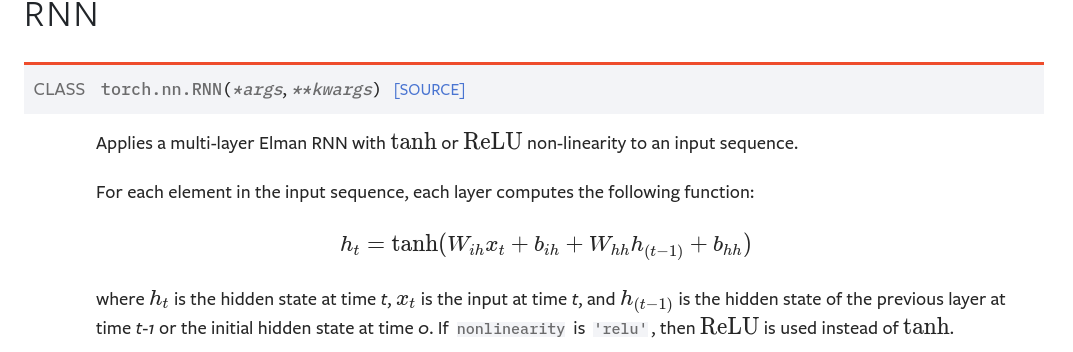

проверяем, равны ли последние выходные данные RNN (на последнем временном шаге) и скрытое состояние, полученное после обработки всей последовательности.

In [14]:
(output[-1, :, :] == hn[-1, :, :]).all()

tensor(True)

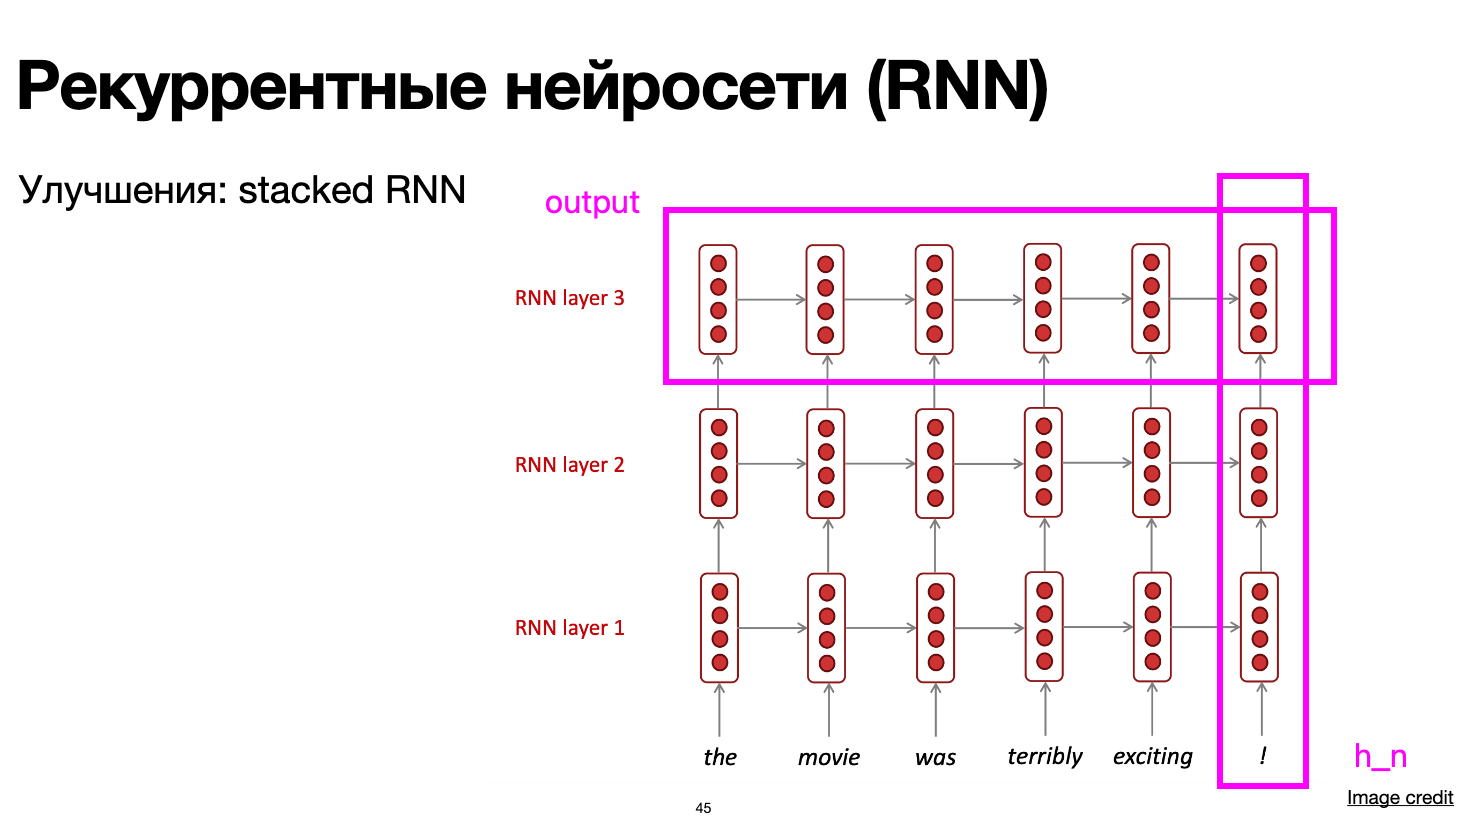

##### **Вопрос:** Зачем тогда возвращать hn, если можно просто сделать `output[-1, :, :]`

#### Посмотрим, какие параметры есть в рннке

Создаем список имен параметров для рекуррентной нейронной сети (RNN) и выводит их размеры.
Здесь создается список имен параметров, который содержит названия весов и смещений для двух слоев RNN. Параметры RNN включают:

    W_ih — веса для входов, связанных со скрытым состоянием.
    W_hh — веса для скрытого состояния, связанного с самим собой.
    b_ih — смещения для входов.
    b_hh — смещения для скрытого состояния.
    
Умножив список на 2, вы создаете дубликаты, что актуально, если ваша RNN имеет два слоя.

rnn.parameters() возвращает итератор по всем параметрам модели, что в данном случае включает веса и смещения.
map(lambda x: x.shape, rnn.parameters()) создает список форм (размеров) для каждого параметра.
zip(parameters_names, ...) объединяет имена параметров и их размеры в пары.
Внутри цикла for происходит вывод имени параметра и его формы.

In [15]:
# (W_ih W_hh, b_ih, b_hh) * 2

parameters_names = [ 'W_ih', 'W_hh', 'b_ih', 'b_hh' ] * 2
for name, p_shape in zip(parameters_names, list(map(lambda x: x.shape, rnn.parameters()))):
    print(name, ":", p_shape)

W_ih : torch.Size([20, 10])
W_hh : torch.Size([20, 20])
b_ih : torch.Size([20])
b_hh : torch.Size([20])
W_ih : torch.Size([20, 20])
W_hh : torch.Size([20, 20])
b_ih : torch.Size([20])
b_hh : torch.Size([20])


#### Кол-во параметров


In [18]:
count_params(rnn)

1480

### Своя реализация

In [19]:
import torch
import torch.nn as nn

class MyRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(MyRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Слои для входных данных и скрытых состояний
        self.i2h = nn.Linear(input_size, hidden_size) 
        self.h2h = nn.Linear(hidden_size, hidden_size)
        # Инициализация скрытого состояния
        self.hidden = None

    def forward(self, input):
        # input [seq_len, batch_size, input_dim]
        # Инициализация скрытого состояния для каждого слоя
        self.hidden = self.init_hidden(input.size(1))
        output = []
        for i in range(input.shape[0]):
            output.append(self.hidden)
            self.hidden = torch.tanh(self.i2h(input[i, :, :]) + self.h2h(self.hidden))
        output = torch.cat(output)  # [seq_len, bs, hidden_dim] 
        return output, self.hidden

    def init_hidden(self, batch_size):
        # Инициализация скрытого состояния с нуля
        return torch.zeros(self.num_layers, batch_size, self.hidden_size)

# Параметры модели
n_hidden = 128
n_letters = 26
n_layers = 2  # Число слоев
rnn = MyRNN(n_letters, n_hidden, n_layers)

# Пример входа (seq_len, batch_size, input_dim)
input_data = torch.randn(10, 5, n_letters)  # Например, последовательность из 10 элементов, батч из 5
output, hidden = rnn(input_data)

print(output.shape)  # Проверка формы выходных данных
print(hidden.shape)  # Проверка формы скрытого состояния


torch.Size([20, 5, 128])
torch.Size([2, 5, 128])


In [20]:
output

tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[-0.1445,  0.6832, -0.4085,  ...,  0.3439,  0.3109, -0.7567],
         [ 0.5210,  0.2158,  0.3169,  ...,  0.6694, -0.3006, -0.1392],
         [ 0.3377,  0.1760,  0.4514,  ..., -0.6097, -0.1679,  0.6876],
         [-0.2573,  0.0198,  0.2221,  ...,  0.0984,  0.4773, -0.0209],
  